<a href="https://colab.research.google.com/github/azimrsli/ldcw/blob/main/DRAFT_PROJECT_TML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Import Libraries and Load Dataset

In this phase, we:
- Install required dependencies (`kagglehub`, `xgboost`, `shap`, `imbalanced-learn`) quietly.
- Import all required Python libraries.
- Download the dataset via KaggleHub.
- Perform an initial inspection of the data (shape, types, class balance).


In [ ]:
# ============================================================
# Step 1.1 — Install required dependencies (quietly)
# ============================================================
!pip install -q kagglehub xgboost shap imbalanced-learn
print(' Dependencies installed successfully.')


 Dependencies installed successfully.


In [ ]:
# ============================================================
# Step 1.2 — Import all req libraries
# ============================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Third-party models and tools
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import kagglehub
import shap

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(' All libraries imported successfully.')


✅ All libraries imported successfully.


In [ ]:
# ============================================================
# Step 1.3 — Download the dataset using kagglehub
# ============================================================
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/online-shoppers-purchasing-intention-dataset")

print("Path to dataset files:", path)

# ============================================================
# Step 1.4 — Load the CSV into a Pandas DataFrame
# ============================================================
csv_file = os.path.join(path, "online_shoppers_intention.csv")
df = pd.read_csv(csv_file)

print(f"\nDataset shape : {df.shape}")
print(f"# Features    : {df.shape[1] - 1}")
print(f"# Samples     : {df.shape[0]}")
df.head()


100%|██████████| 252k/252k [00:00<00:00, 342kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/imakash3011/online-shoppers-purchasing-intention-dataset/versions/1

Dataset shape : (12330, 18)
# Features    : 17
# Samples     : 12330


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# ============================================================
# Step 1.5 — Initial inspection
# ============================================================
print("=== DataFrame Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14 

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


=== Target Distribution (Revenue) ===
Revenue
False    10422
True      1908
Name: count, dtype: int64

Class balance (%):
Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


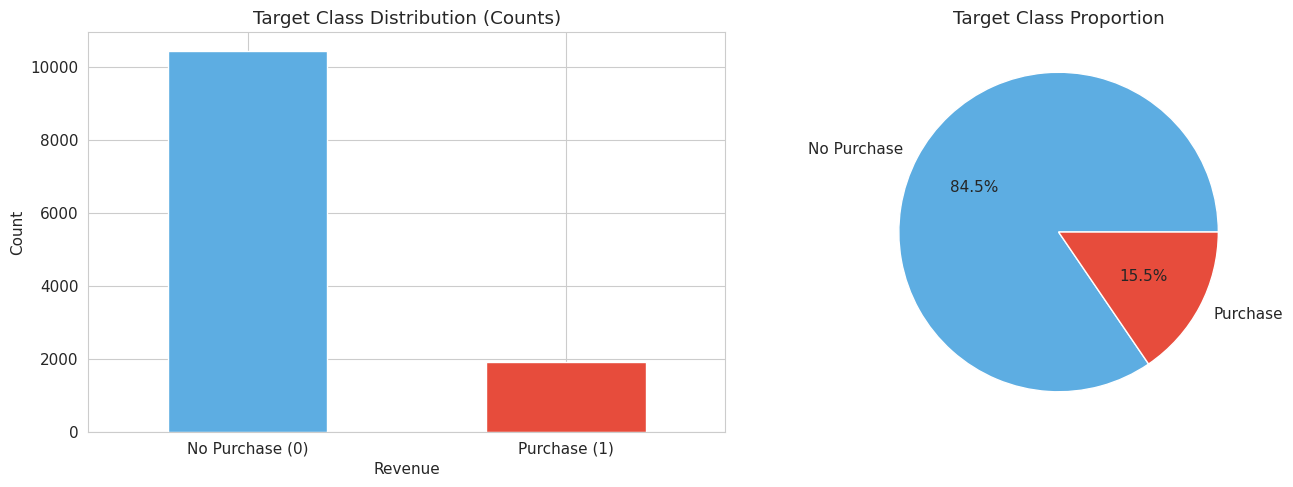

In [ ]:
# ============================================================
# Step 1.6 — Class balance check for the 'Revenue' target
# ============================================================
print("=== Target Distribution (Revenue) ===")
print(df['Revenue'].value_counts())
print(f"\nClass balance (%):\n{df['Revenue'].value_counts(normalize=True).round(4) * 100}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Revenue'].value_counts().plot(kind='bar', ax=axes[0], color=['#5DADE2', '#E74C3C'])
axes[0].set_title('Target Class Distribution (Counts)')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Purchase (0)', 'Purchase (1)'], rotation=0)

df['Revenue'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#5DADE2', '#E74C3C'], labels=['No Purchase', 'Purchase'])
axes[1].set_title('Target Class Proportion')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


## Phase 2: Pre-processing and Feature Engineering

In this phase, we:
- Check for and systematically handle **missing values** and duplicates.
- **Encode categorical features** (`Month`, `VisitorType`) using One-Hot Encoding.
- Convert boolean columns (`Revenue`, `Weekend`) to binary `int` (0/1).
- **Scale continuous features** using `StandardScaler`.
- Address severe **class imbalance** using **SMOTE** (Synthetic Minority Over-sampling Technique) — emphasized in the assignment report as a critical pre-processing step.
- Perform a clean **stratified train/test split** (80/20) to preserve class ratios.


In [ ]:
# ============================================================
# Step 2.1 — Handle missing values & duplicates
# ==========================================================
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found in the dataset.")

duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicate rows to remove.")


=== Missing Values per Column ===
✅ No missing values found in the dataset.

Number of duplicate rows: 125
✅ Duplicates removed. New shape: (12205, 18)


In [ ]:
# ============================================================
# Step 2.2 — Inspect categorical / boolean columns
# ============================================================
print("=== Categorical (object) columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].unique()}")

print("\n=== Boolean columns ===")
for col in df.select_dtypes(include='bool').columns:
    print(f"  {col}: {df[col].unique()}")


=== Categorical (object) columns ===
  Month: ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
  VisitorType: ['Returning_Visitor' 'New_Visitor' 'Other']

=== Boolean columns ===
  Weekend: [False  True]
  Revenue: [False  True]


In [ ]:
# ============================================================
# Step 2.3 — Encode categorical features (One-Hot Encoding)
#         and convert boolean columns to 0/1
# ============================================================
df_processed = df.copy()

# Convert boolean columns to int (Revenue is the target, Weekend is a feature)
df_processed['Revenue'] = df_processed['Revenue'].astype(int)
df_processed['Weekend'] = df_processed['Weekend'].astype(int)

# One-Hot Encode 'Month' and 'VisitorType'
df_processed = pd.get_dummies(
    df_processed,
    columns=['Month', 'VisitorType'],
    drop_first=False,
)

print(f"Shape after encoding: {df_processed.shape}")
print(f"Total columns: {len(df_processed.columns)}")
df_processed.head()


Shape after encoding: (12205, 29)
Total columns: 29


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
# ============================================================
# Step 2.4 — Stratified train/test split (80/20)
# ============================================================
X = df_processed.drop('Revenue', axis=1)
y = df_processed['Revenue']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"\nTraining set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest  class distribution:\n{y_test.value_counts()}")


Feature matrix shape: (12205, 28)
Target vector shape : (12205,)

Training set : (9764, 28)
Test set     : (2441, 28)

Train class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test  class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 2.5 — Feature scaling (StandardScaler)
# ============================================================
numerical_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data only, then transform both sets
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(" Feature scaling complete.")
print("\nSample of scaled training features (first 3 rows of numerical columns):")
print(X_train_scaled[numerical_cols].head(3))

# ============================================================
# Step 2.6 — Address class imbalance with SMOTE
# ============================================================
print("\n=== Before SMOTE ===")
print(f"Train class distribution:\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n=== After SMOTE ===")
print(f"Train resampled shape: {X_train_resampled.shape}")
print(f"Train resampled class distribution:\n{pd.Series(y_train_resampled).value_counts()}")


✅ Feature scaling complete.

Sample of scaled training features (first 3 rows of numerical columns):
       Administrative  Administrative_Duration  Informational  \
7469         1.689206                 0.676238       0.381750   
11804       -0.699498                -0.458067      -0.397879   
3250        -0.699498                -0.458067      -0.397879   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
7469                -0.243015        0.220868                -0.080395   
11804               -0.243015       -0.046900                -0.158842   
3250                -0.243015       -0.426237                -0.408089   

       BounceRates  ExitRates  PageValues  SpecialDay  
7469     -0.448703  -0.800192    1.665596   -0.311837  
11804    -0.448703  -0.739774    1.495448   -0.311837  
3250     -0.448703  -0.287446   -0.315264    3.689185  

=== Before SMOTE ===
Train class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

=== After SMOT

## Phase 3: Model Training and Tuning

In this phase, we:
- Initialize the **three** required models: **Logistic Regression**, **Random Forest**, and **XGBoost**.
- Tune their hyperparameters with `GridSearchCV` and **stratified 5-fold cross-validation** (scoring metric: ROC-AUC).
- Print the **best hyperparameters** discovered for each model.
- Train the final, tuned versions of all 3 models on the (SMOTE-resampled) training set.


In [ ]:
# ============================================================
# Step 3.1 — Tune Logistic Regression (Baseline)
# ============================================================
print("="*60)
print("Tuning Logistic Regression")
print("="*60)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    lr_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)
lr_grid.fit(X_train_resampled, y_train_resampled)

print(f"\nBest Parameters : {lr_grid.best_params_}")
print(f"Best CV ROC-AUC : {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_


Tuning Logistic Regression

Best Parameters : {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC : 0.9464


In [ ]:
# ============================================================
# Step 3.2 — Tune Random Forest (Bagging Ensemble)
# ============================================================
print("="*60)
print("Tuning Random Forest")
print("="*60)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)
rf_grid.fit(X_train_resampled, y_train_resampled)

print(f"\nBest Parameters : {rf_grid.best_params_}")
print(f"Best CV ROC-AUC : {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_


Tuning Random Forest

Best Parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC : 0.9838


In [ ]:
# ============================================================
# Step 3.3 — Tune XGBoost (Gradient Boosting Ensemble)
# ============================================================
print("="*60)
print("Tuning XGBoost")
print("="*60)

neg, pos = (y_train_resampled == 0).sum(), (y_train_resampled == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight (neg/pos): {scale_pos:.2f}")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        n_jobs=-1,
    ),
    xgb_params,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)
xgb_grid.fit(X_train_resampled, y_train_resampled)

print(f"\nBest Parameters : {xgb_grid.best_params_}")
print(f"Best CV ROC-AUC : {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_


Tuning XGBoost
scale_pos_weight (neg/pos): 1.00

Best Parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC : 0.9862


In [ ]:
# ============================================================
# Step 3.4 — Final training (the tuned estimators are already fit)
#          + summary of best hyperparameters
# ============================================================
print("\n" + "="*60)
print("SUMMARY OF BEST HYPERPARAMETERS")
print("="*60)
print(f"\nLogistic Regression : {lr_grid.best_params_}")
print(f"   -> CV ROC-AUC     : {lr_grid.best_score_:.4f}")
print(f"\nRandom Forest        : {rf_grid.best_params_}")
print(f"   -> CV ROC-AUC     : {rf_grid.best_score_:.4f}")
print(f"\nXGBoost              : {xgb_grid.best_params_}")
print(f"   -> CV ROC-AUC     : {xgb_grid.best_score_:.4f}")

print("\n All three tuned models are ready for evaluation.")



SUMMARY OF BEST HYPERPARAMETERS

Logistic Regression : {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
   -> CV ROC-AUC     : 0.9464

Random Forest        : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
   -> CV ROC-AUC     : 0.9838

XGBoost              : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
   -> CV ROC-AUC     : 0.9862

✅ All three tuned models are ready for evaluation.


## Phase 4: Evaluation and Visualizations

In this phase, we:
- Generate predictions on the **test set** for all 3 models.
- For each model, calculate and display the **Classification Report** (Accuracy, Precision, Recall, F1-Score).
- Display the **Confusion Matrix** for each model.
- Calculate the **ROC-AUC score** for each model.
- Produce a side-by-side **bar chart** comparing Precision, Recall, and F1 across the 3 models.
- Plot a **combined ROC-AUC curve** overlaying all 3 models.
- Apply **SHAP (Explainable AI)** on the best tree ensemble to identify the session features driving purchase intent.


In [ ]:
# ============================================================
# Step 4.1 — Predict on the test set & compute metrics
# ============================================================
models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
}

results = {}

for name, model in models.items():
    print("="*60)
    print(f"Model: {name}")
    print("="*60)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy':  accuracy,
        'Precision': precision,
        'Recall':    recall,
        'F1-Score':  f1,
        'ROC-AUC':   roc_auc,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase'])}")


Model: Logistic Regression
Accuracy  : 0.8660
Precision : 0.5584
Recall    : 0.6885
F1-Score  : 0.6166
ROC-AUC   : 0.8929

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.94      0.90      0.92      2059
    Purchase       0.56      0.69      0.62       382

    accuracy                           0.87      2441
   macro avg       0.75      0.79      0.77      2441
weighted avg       0.88      0.87      0.87      2441

Model: Random Forest
Accuracy  : 0.8923
Precision : 0.6368
Recall    : 0.7251
F1-Score  : 0.6781
ROC-AUC   : 0.9266

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.94      2059
    Purchase       0.64      0.73      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.82      0.81      2441
weighted avg       0.90      0.89      0.90      2441

Model: XGBoost
Accuracy  : 0.8939
Precision : 0.6541
Recall 

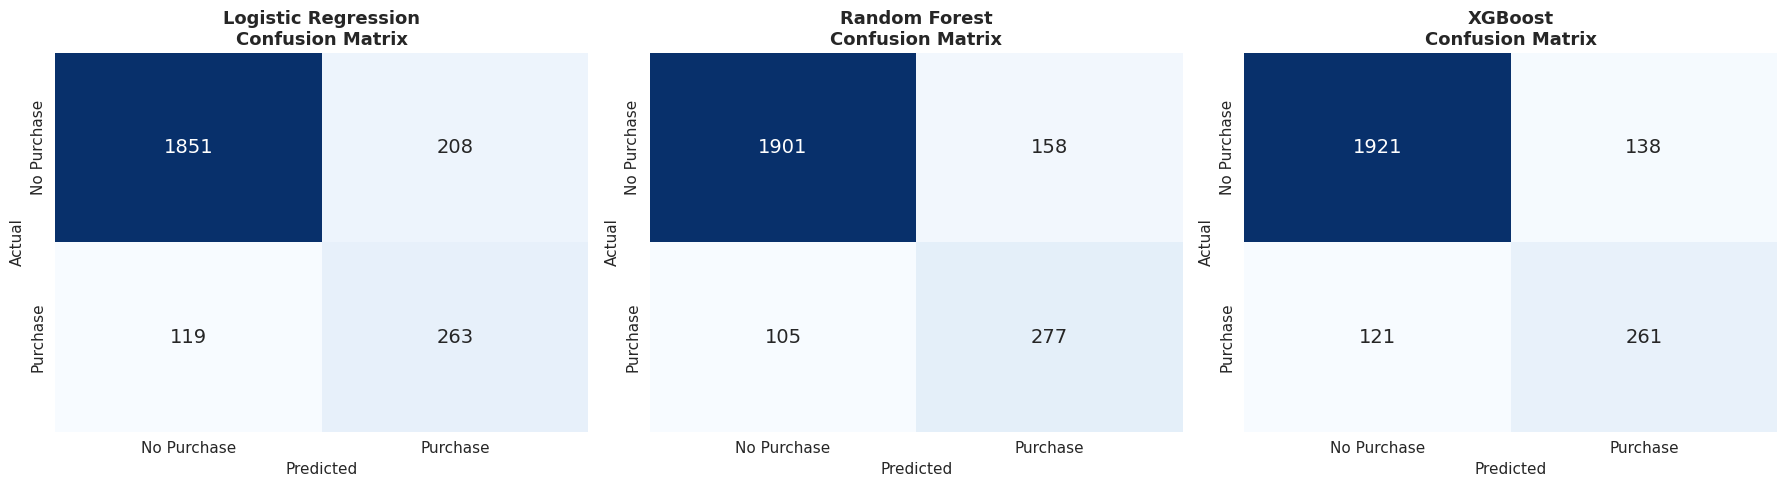

In [ ]:
# ============================================================
# Step 4.2 — Confusion Matrices (one subplot per model)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['No Purchase', 'Purchase'],
        yticklabels=['No Purchase', 'Purchase'],
        cbar=False, annot_kws={'size': 14},
    )
    axes[idx].set_title(f"{name}\nConfusion Matrix", fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


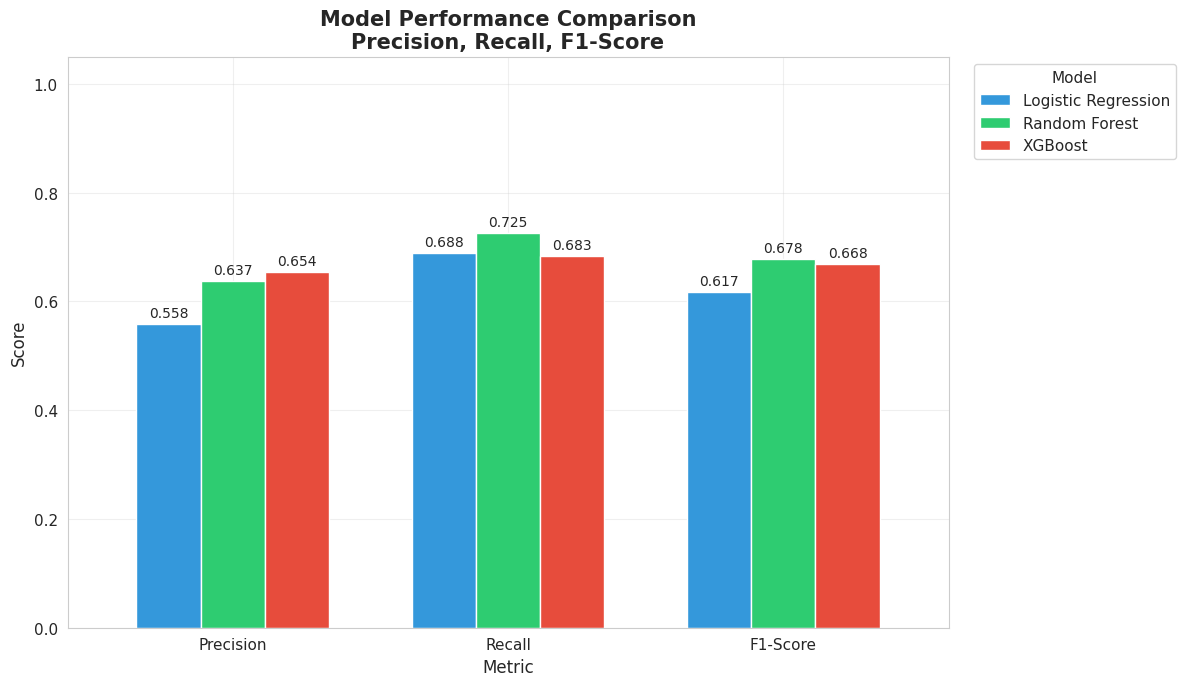

In [ ]:
# ============================================================
# Step 4.3 — Comparison Bar Chart (Precision, Recall, F1-Score)
# ============================================================
metrics_df = pd.DataFrame({
    name: [res['Precision'], res['Recall'], res['F1-Score']]
    for name, res in results.items()
}, index=['Precision', 'Recall', 'F1-Score'])

fig, ax = plt.subplots(figsize=(12, 7))
metrics_df.plot(kind='bar', ax=ax, color=['#3498DB', '#2ECC71', '#E74C3C'], width=0.7)
ax.set_title('Model Performance Comparison\nPrecision, Recall, F1-Score', fontsize=15, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.set_ylim(0, 1.05)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Add value labels on top of each bar
for container in ax.containers:
    labels = [f'{v.get_height():.3f}' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.tight_layout()
plt.show()


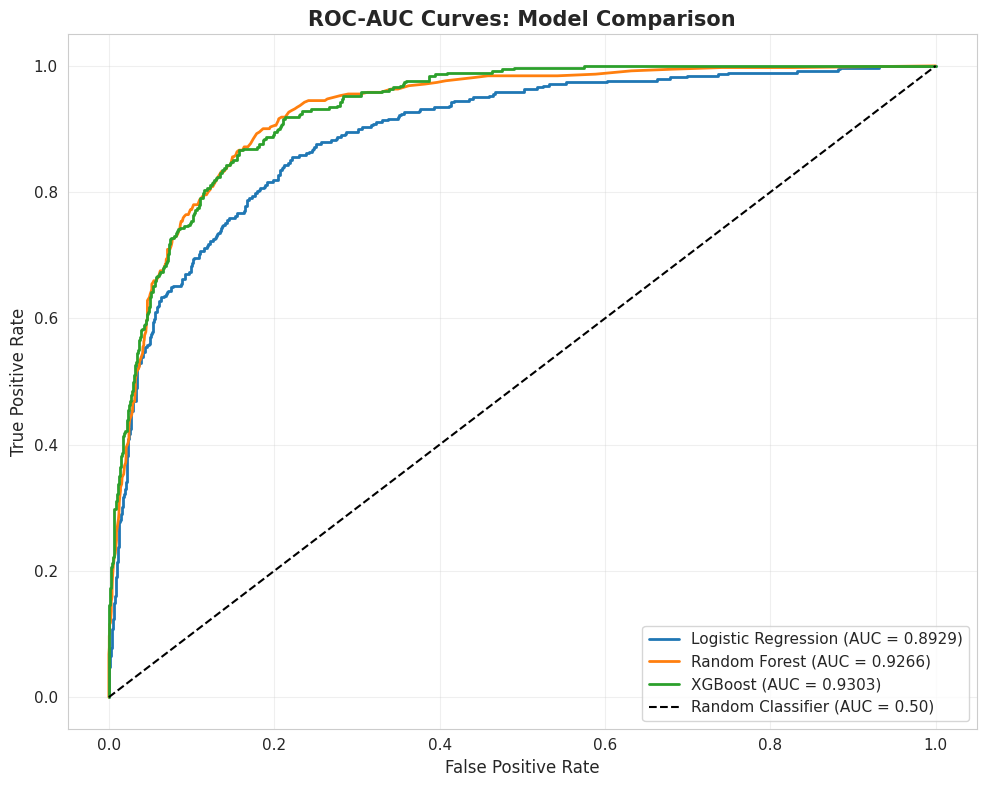

In [ ]:
# ============================================================
# Step 4.4 — Combined ROC-AUC Curves (all 3 models)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.4f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)', linewidth=1.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curves: Model Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 4.5 — Explainable AI (SHAP) on the best tree ensemble
# ============================================================
# Identify the best-performing model by ROC-AUC
best_model_name = max(results, key=lambda k: results[k]['ROC-AUC'])
print(f" Best performing model : {best_model_name}")
print(f"   Best ROC-AUC         : {results[best_model_name]['ROC-AUC']:.4f}")

# Per project spec: SHAP explainer MUST be on a tree ensemble model
# (XGBoost or Random Forest) — never on the linear baseline.
if best_model_name == 'XGBoost':
    tree_model = best_xgb
    tree_model_name = 'XGBoost'
elif best_model_name == 'Random Forest':
    tree_model = best_rf
    tree_model_name = 'Random Forest'
else:
    # Logistic Regression was best — use XGBoost (next best ensemble) for SHAP
    print("   Using XGBoost for SHAP analysis (tree-based ensemble).")
    tree_model = best_xgb
    tree_model_name = 'XGBoost'

# Build a TreeExplainer (fast, model-specific, exact for tree ensembles)
explainer = shap.TreeExplainer(tree_model)

# Compute SHAP values on a sample of test data (keeps the plot responsive)
shap_sample = X_test_scaled.sample(n=min(500, len(X_test_scaled)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Random Forest (binary) may return a 3D array; XGBoost returns 2D. Normalise.
shap_array = np.array(shap_values)
if shap_array.ndim == 3:
    shap_values_to_plot = shap_array[:, :, 1]   # positive class
else:
    shap_values_to_plot = shap_array

print(f"\n SHAP values computed for {tree_model_name} on {len(shap_sample)} test samples.")
print(f"   shap_values shape : {shap_array.shape}")


 Best performing model : XGBoost
   Best ROC-AUC         : 0.9303

 SHAP values computed for XGBoost on 500 test samples.
   shap_values shape : (500, 28)


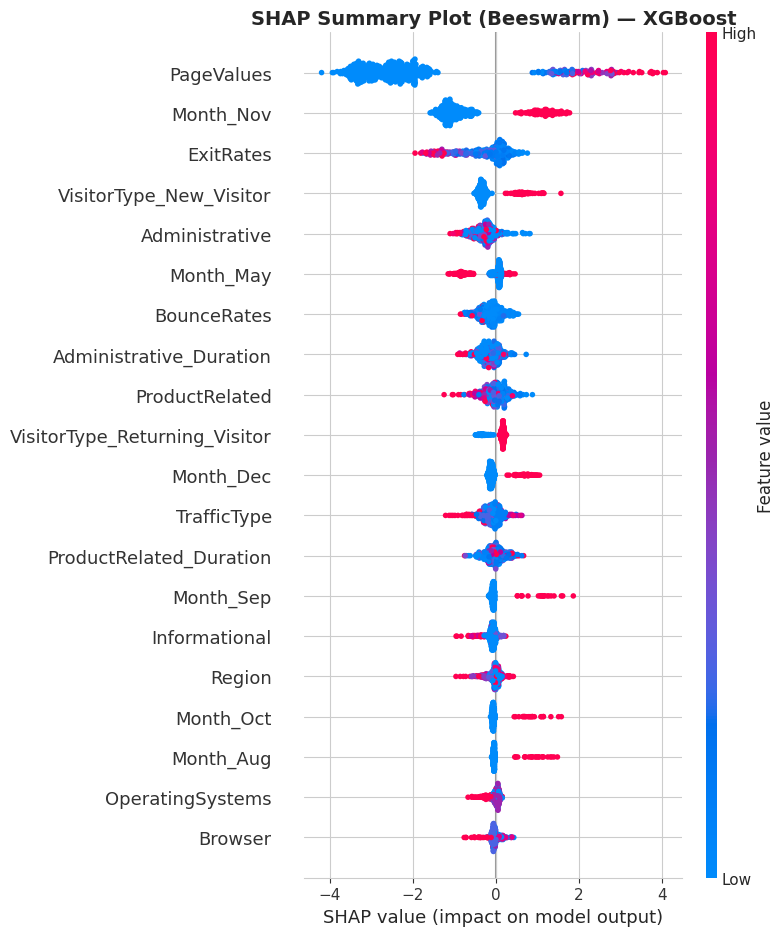

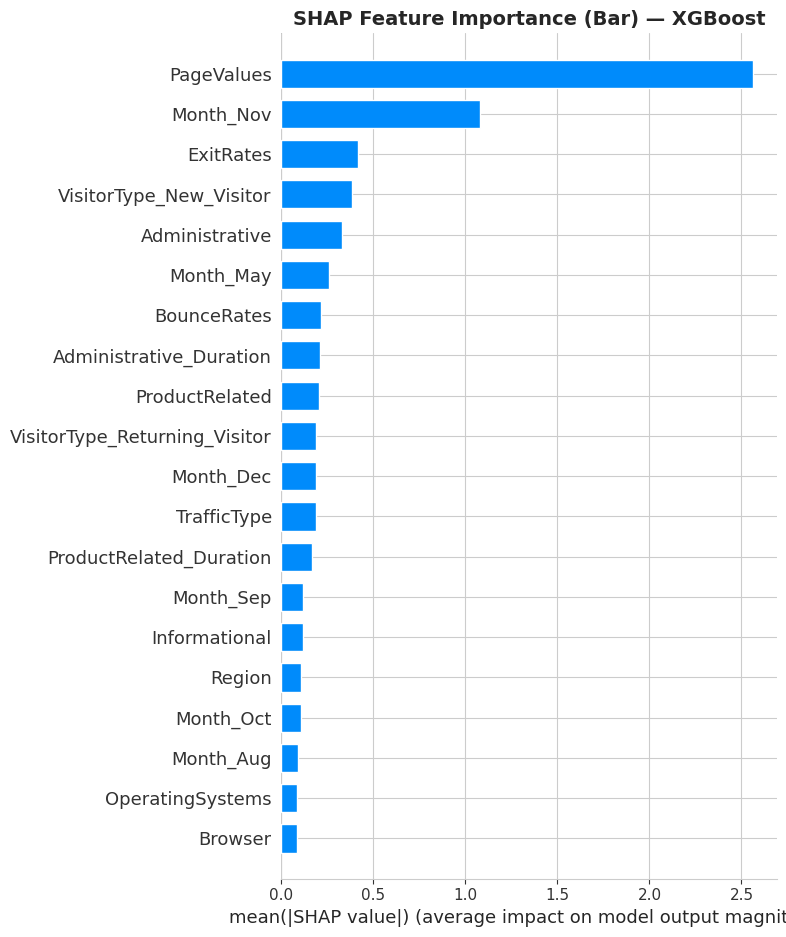

In [ ]:
# ============================================================
# Step 4.6 — SHAP Visualisations
# ============================================================
# (a) Beeswarm Summary Plot — shows direction & magnitude of each feature's impact
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_to_plot, shap_sample, plot_type='dot', show=False)
plt.title(f'SHAP Summary Plot (Beeswarm) — {tree_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# (b) Bar Plot — global feature importance (mean |SHAP|)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_to_plot, shap_sample, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance (Bar) — {tree_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
